# Relation 1. Physics of Complex Systems. 

Diego Contreras Olmos

### Exercise 1: ENTROPY

• **Create several files with 1-million one-digit numbers and different amount of randomness**

    – A deterministic one in the format “11111111”.

    – A total random one.

    – One where the probability of a number is proportional to the number itself.

    – Any other distribution you can think of.


• **Calculate Shannon’s entropy of the files.**

• **Compress the files with ZIP and calculate the compression ratio.**

• **Plot the compression ratio against Shanon’s entropy. What is the relation between these two
quantities?**

• **Try to find a protocol that “cheats”, meaning that it has a high entropy but it can be efficiently
compressed.**


In [39]:
#Librerías

import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
from scipy.stats import norm

In [40]:
#General parameters

Total_N = 1000000       #One million numbers
directorio = "entropy"  #Bin where we will store everything
os.makedirs(directorio, exist_ok=True)

#Create a function to save the numbers created by the different distributions

def savenumbers(file, number):
    """Save the number into the file 'file'

    Args:
        file (file): Where do you wanna store it?
        number (natural number): The number you wanna store
    """
    path = os.path.join(directorio, file)
    with open(path, "w") as f:
        f.write("".join(map(str, number)))      #This way the numbers are all together (I had to look it up)
    return path

In [41]:
#CODE: Distributions to generate numbers #############################################

#Create a void vector to put the info there
files = []

#1.- All are 1

number1 = np.ones(Total_N, dtype=int) #Use dtype to ensure they are not 1.0 #######################
path1 = savenumbers("1_all1.txt", number1)
files.append(("All_are_1", path1, number1))



#2.- Total random one: I believe this is equally probable from 0 to 9 ~#########################
number2 = np.random.randint(0,10, size=Total_N)
path2 = savenumbers("2_uniform.txt", number2)
files.append(("Uniformly random", path2, number2))



#3.- Proability proportional to the number itself. ##############################################

#Let us create a weighted distribution, linear in this case

valores3 = np.arange(10)
pesos3 = np.arange(1,11) #This way the number 0 can also appear
probabilidad3 = pesos3/pesos3.sum() #Normalize

number3 = np.random.choice(valores3, size=Total_N, p=probabilidad3)
path3 = savenumbers("3_proportional.txt", number3)
files.append(("Uniformly proportional", path3, number3))



#4.- My choice for distribution: Gaussian centered in 5

mu = 5
sigma = 1 #for example

number4 = np.random.normal(mu,sigma,size=Total_N) #this creates floats, let us round
number4 = np.round(number4) #We have whole numbers from -inf to +inf, we will take only from 0 to 9, because they are small, it will be negligible
number4 = np.clip(number4, 0, 9)    #Now we have natural numbers, but in the form of 0.0, 1.0, etc.
number4 = number4.astype(int)
path4 = savenumbers("4_gausiana.txt", number4)
files.append(("Gaussian distribution", path4, number4))




In [42]:
###CODE: SHANON ENTROPY ###############################

#Create a function to count the entropy

def shannon(number):
    """Calculate the shannon entropy of a file

    Args:
        number (vector): array of numbers

    Returns:
        _type_: the float H of the file
    """
    count=np.bincount(number)   #Counts how many times does a number appear
    prob = count[count >0] /len(number) #Calculate the probability as the counted number / 1000000 (in this case), the length
    H = -np.sum(prob*np.log2(prob))     #Shanon's entropy is defined as -Sum (P_i * log(P_i)) with the logarithm in base 2, bits
    return H


#Now, let us calculate the entropy of the files

for i, (name, path, number) in enumerate(files):
    H=shannon(number)
    files[i]=(name, path, number, H)

print("Entropy: ")
for name,path,number,H in files:
    print(f"{name:25s}, H= {H:.6f} bits")

Entropy: 
All_are_1                , H= -0.000000 bits
Uniformly random         , H= 3.321926 bits
Uniformly proportional   , H= 3.103184 bits
Gaussian distribution    , H= 2.105918 bits


In [43]:
###CODE: Compress the files using ZIP #######################

#Define a function to do so

def zip_file(file):
    """Compress using ZIP

    Args:
        file (file): the path of the file
    """
    zip_path = file.replace(".txt", ".zip")
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        zf.write(file, arcname=os.path.basename(file))
    return zip_path
    
#Create the ratio for the compression, i mean, the ration between weights of bits of the compressed and original files    

resultados = []

for name,path,digits,H in files:
    zip_path = zip_file(path)
    original_size = os.path.getsize(path)
    compressed_size = os.path.getsize(zip_path)
    c_ratio = compressed_size / original_size
    
    #Lets put this clean
    
    resultados.append({
        "name": name,
        "txt_path" : path,
        "zip_path": zip_path,
        "entropy" : H,
        "original_size" : original_size,
        "compressed_size" : compressed_size,
        "compression_ratio" : c_ratio
    })
    

print("Results: ")
for r in resultados:
    print(f"{r["name"]:25s}, H={r["entropy"]:.6f}, ratio = {r["compression_ratio"]:.6f}")


Results: 
All_are_1                , H=-0.000000, ratio = 0.001104
Uniformly random         , H=3.321926, ratio = 0.470665
Uniformly proportional   , H=3.103184, ratio = 0.449141
Gaussian distribution    , H=2.105918, ratio = 0.327475


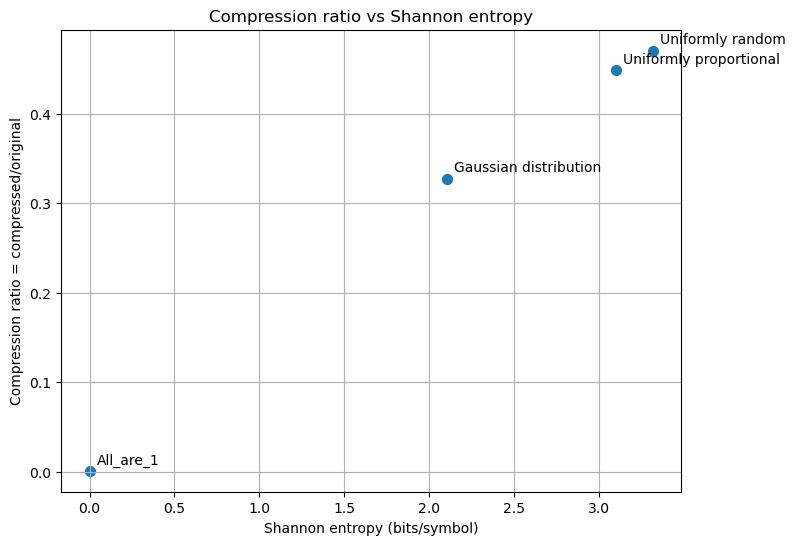

In [44]:
###CODE: PLOT the entropy vs the compression ratio ####################################

entropias = [r["entropy"] for r in resultados]
ratios = [r["compression_ratio"] for r in resultados]
labels = [r["name"] for r in resultados]

plt.figure(figsize=(8,6))
plt.scatter(entropias, ratios, s=50)

for x, y, label in zip(entropias, ratios, labels):
    plt.annotate(label, (x,y), xytext=(5,5), textcoords = "offset points")
    

plt.xlabel("Shannon entropy (bits/symbol)")
plt.ylabel("Compression ratio = compressed/original")
plt.title("Compression ratio vs Shannon entropy")
plt.grid()
plt.show()



In [45]:
###CODE: Cheat method ############################

#We will abuse the definition of shannon's entropy. Zip can see more than just the repetition of the numbers, it sees at a larger scale (sort of).
#For that: create high entropy blocks that repeat.

chain_size = 1000
chain = np.random.randint(0, 10, size=chain_size)

repeats = Total_N // chain_size #Remember we set Total_N to a variable, so we have to know how many blocks we will have
number_cheat = np.tile(chain, repeats)

#If the blocks are not an exact divisor of Total_N, we add part of the chain
if len(number_cheat) < Total_N:
    number_cheat = np.concatenate([number_cheat, chain[:Total_N - len(number_cheat)]])
    

path_cheat = savenumbers("5_cheatcode.txt", number_cheat)
files.append(("Cheating algorithm (repetition)", path_cheat, number_cheat))

H_cheat = shannon(number_cheat)
zip_cheat = zip_file(path_cheat)
original_cheat = os.path.getsize(path_cheat)
compressed_cheat = os.path.getsize(zip_cheat)
ratio_cheat = compressed_cheat/original_cheat

print("Cheat algorithm: ")
print(f"Entropy = {H_cheat}:.6f bits")
print(f"Compression ratio = {ratio_cheat}:.6f")


#As we can see, compression ratio is almost null but entropy is high.

Cheat algorithm: 
Entropy = 3.3178841319905725:.6f bits
Compression ratio = 0.00557:.6f


### Exercise 2:
**Look in the media for a misuse of a statistical concept.
Explain why it is wrong.**

One typical example is that "More vaccinated people died so vaccines don't work". This argument relies on the false premise that the population has the same characteristics and that there are an equal amount of people vaccinated and unvaccinated. Even if (in a global scale) we could neglect the wellbeing of each person and only taking into account the outcome (still alive or dead), we still need to do it per cápita.

Another example is a funny graph I saw on twitter not too long ago. Even if it was a meme, the graph showed correlation between shark attacks and ice cream sales. Truly, they are not correlated, but they do have correlation to summer being hotter and people wanting ice cream and going for a swim.

Finally another example I have seen is relation between coffee and cancer. The article I found is the one criticizing this bad correlation, like I am doing in this exercise. The premise is basically that they took a great sample of people who took coffee for a year and another who didn't. The results did not take into account whether the people smoked, did exercise, had a healthy diet, etc. These are also factors that should be taken into account to not confuse correlation with association.

### Exercise 3: Properties of binomial distribution

For the binomial distribution, $p_n(k) = \binom{n}{k}p^k(1-p)^{n-k}$
, prove that:
1. The Moment Generating Function is $(q + pe^t)^n$, where q = 1 − p.
2. The mean is E[X] = np.
3. The variance is Var(X) = np(1 − p).

**1. The Moment Generating Function is $(q + pe^t)^n$, where q = 1 − p.**

We know the moment generating function is $$M_X(t) = E[e^{tX}]$$ where E is the expected value

Because X is discrete (binomial) then $$M_X(t) = \sum_{k=0}^n e^{tk}P(X=k) = \sum_{k=0}^n e^{tk} \binom{n}{k}p^kq^{n-k} = \sum_{k=0}^n \binom{n}{k}(pe^t)^kq^{n-k}$$

Now, develop the binomial, using $$(a+b)^n = \sum_{k=0}^n \binom{n}{k}a^kb^{n-k}$$ we can see $a = pe^t$ and $b=q$

With this, we arrive to the result $$M_X(t) = (q+pe^t)^n$$


**2. The mean is E[X] = np.**

The first derivative of the moment generating function is the mean, so lets do it. We will use the result from before.

$E[X] = M'_X(0)$

We derive $$M'_X(t) = npe^t(q+pe^t)^{n-1}$$

Now use at t=0, $e^t =1$ and that q=1-p so $p+q = 1$; $$M'_X(0) = np(q+p)^{n-1} = np(1)^{n-1} = np$$

Then E[X] = np

**3. The variance is Var(X) = np(1 − p).**

Now, starting from the definition that $M''_X(0) = E[X^2]$ and that $Var(X) = E[X^2]-(E[X])^2$

Let us do the same procedure, first derivate again M.

$$M''_X(t) = n\left(  pe^t(n-1)pe^t(q+pe^t)^{n-2} + pe^t(q+pe^t)^{n-1}    \right)$$

We regroup and use t=0

$$M''_X(0) = n\left( (n-1)p^2(q+p)^{n-2} + p(q+p)^{n-1} \right) = n[(n-1)p^2 + p] = E[X^2]$$

Now using that $(E[X])^2 = n^2p^2$, we calculate the variance

$$Var(X) = E[X^2] - (E[X])^2 = n[(n-1)p^2 + p] - n^2p^2 = -np^2 +np = np(1-p) = npq$$

### Exercise 4: Central Limit Theorem

Let $X_i$, $i\in \mathbb{N}$ be independent, identically distributed (i.i.d.) random variables with mean $\mu$ and variance $\sigma^2 < \infty$. 
Let $S_n$ be the random variable describing the partial sums of the sequence $\{X_i\}_{i\in \mathbb{N}}$: $S_n = \sum_i X_i$. You have to prove that:

$$Z_n=\frac{S_n-E[S_n]}{\sigma(S_n)}=\frac{S_n-n\mu}{\sigma\sqrt{n}}$$

converges to a standard normal random variable as $n$ goes to infinity. For that, follow these steps:

**1. Prove that $M_{Z_n}(t)=\left[ M_{Y_1}\left(\frac{t}{\sqrt{n}}\right) \right]^n$**

where $Y_i$ is the random variable: $Y_i=\frac{X_i-\mu}{\sigma}$ centered and standardized. To keep the notation simple, from now on, just write:
$M_Y(t)$ instead of $M_{Y_1}(t)$.

We have that $Y_i = \frac{X_i - \mu}{\sigma}$, so $X_i - \mu = \sigma Y_i$.

If we sum them all then $$\sum_{i=1}^n (X_i - \mu) = \sigma\sum_{i=1}^n Y_i = \sum_{i=1}^n (X_i) -n\mu = S_n - n\mu$$

So the truly definition of $Z_n$ in terms of $Y_i$ is $$Z_n = \frac{S_n - n\mu}{\sigma \sqrt{n}} = \frac{1}{\sqrt{n}}\sum_{i=1}^nY_i$$

Now lets start with the moment generating function
$$ M_{Z_n}(t) = E[e^{tZ_n}] = E[\exp{\left(\frac{t}{\sqrt n} \sum_{i=1}^{n}Y_i\right)}] = E[\prod_{i=1}^n\exp\left( \frac{t Y_i}{\sqrt n}\right)]$$

We can use that $Y_i$ are independent, so the expected value of the product is the product of expected values
$$ M_{Z_n}(t) = \prod_{i=1}^n E\left[\exp \left(\frac{tY_i}{\sqrt n}\right)\right] $$

What we have at the right hand side is the product of every moment generating function of $Y_i$, but they say $X_i$ are identically distributed and so because of the definition of $Y_i$, they also are identically distributed, so $M_{Y_i} = M_{Y_1} = M_Y$

$$ M_{Z_n}(t) = \prod_{i=1}^n E\left[\exp \left(\frac{tY_i}{\sqrt n}\right)\right] = \left[ M_Y (\frac{t}{\sqrt n})\right]^n$$




**2. Prove that $M_Y(t)=1+\frac{1}{2}t^2+o(t^3)$**

Plug this into the equation for $M_{Z_n}(t)$. Take the limit when $n\to\infty$ to get: $M_{Z_n}(t)\to \exp\left(\frac{t^2}{2}\right)$

Let us expand $M_Y = E[e^{tY}]$ with Taylor series, so that:

$$M_Y(t) = E\left[ 1 + tY + t^2Y^2/2 + t^3Y^3/6 + ... \right] = 1 + tE[Y] + t^2E[Y^2]/2 + ...$$

Let us calculate $E[Y]$ and $E[Y^2]$
$$E[Y] = E[\frac{X - \mu}{\sigma}] = (E[X] - \mu /\sigma) = (\mu - \mu)/\sigma = 0$$

$$E[Y^2] = Var(Y) = E\left[\frac{(X-\mu)^2}{\sigma^2}\right] = \frac{1}{\sigma^2}E[(X-\mu)^2] = \frac{Var(X)}{\sigma^2} = \frac{\sigma^2}{\sigma^2} = 1$$

So our expansion looks like this:

$$M_Y(t) = 1 + 1/2t^2 + o(t^3) + ...$$


Now we will take the limit when n tends to infinity for $M_{Z_n} = \left[ M_Y \frac{t}{\sqrt n}\right]^n$

$$M_{Z_n}(t) = \left[ 1 + \frac{t^2}{2n} + o(\frac{t^3}{n^{3/2}}) \right]^n $$

Neglecting the term corresponding to $t^3$ and beyond and using the classical limit for n tending to infinity for number e:

$$(1+\frac{a}{n})^n \to e^a$$

Then we get our result:

$$M_{Z_n} (t)\to e^{t^2/2}$$


**3. Conclude that $Z_n$ converges to a standard normal random variable**

If two variables have the same moment generating function then they have the same distribution. For a standard normal random variable we have that $M_Z(t) = e^{t^2/2}$ (with $Z \in N(0,1)$)

This result is equal to the one we obtained earlier, so that means $Z_n$ converges to a standard normal random variable

**4. As a numerical test, generate samples of i.i.d. random variables with different distributions
(Bernoulli, Uniform, etc.) and test that the standardized sum of all of them, Zn is distributed
as a Gaussian in the limit n → ∞.**

In [46]:
### PARAMETERS ################

totalnumber = 10000                #Total number of samples of different distributions
n_values = [5, 20, 50, 100, 500]    #number of possibilities

prob = 0.3      #Bernoulli probability

x = np.linspace(-5, 5, 1000)
gausiana = (1/np.sqrt(2*np.pi)*np.exp(-x**2/2))                          

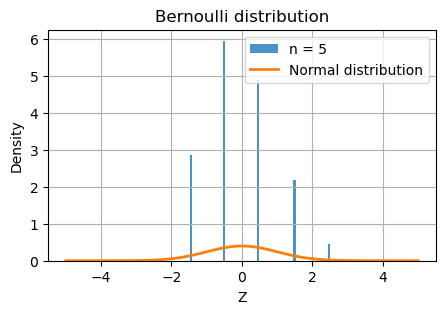

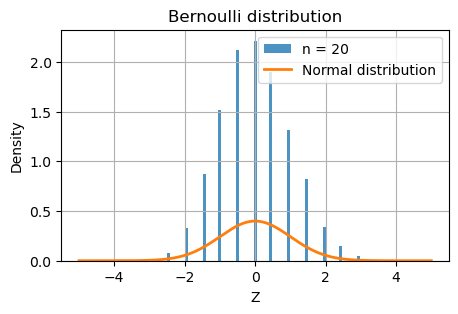

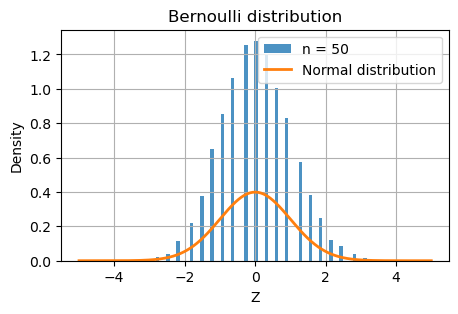

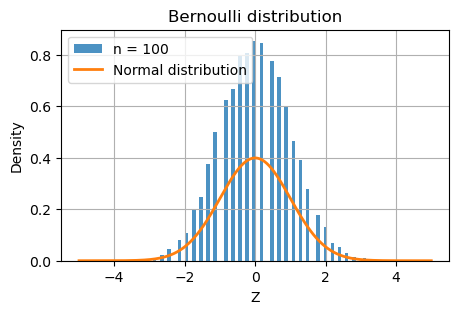

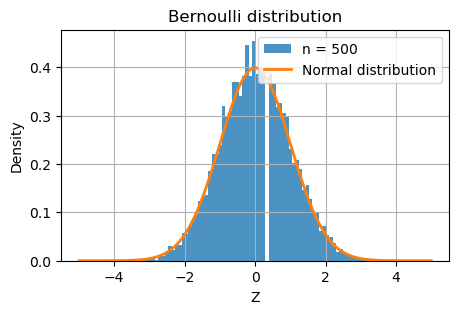

In [47]:
### CODE FOR BERNOULLI ###############

mu_bernoulli = prob
sigma_bernoulli = np.sqrt(prob*(1-prob))

#Now we calculate the independent variable X, then S, then Z

for n in n_values:
    X = np.random.binomial(1, prob, size=(totalnumber,n))
    S = np.sum(X, axis=1)
    Z = (S-n*mu_bernoulli)/(sigma_bernoulli*np.sqrt(n))
    
    
    plt.figure(figsize=(5,3))
    plt.hist(Z, bins=80, density=True, alpha=0.8, label=f"n = {n}")
    plt.plot(x, gausiana, linewidth=2, label='Normal distribution')
    plt.xlabel("Z")
    plt.ylabel("Density")
    plt.title("Bernoulli distribution")
    plt.grid()
    plt.legend()
    plt.show()


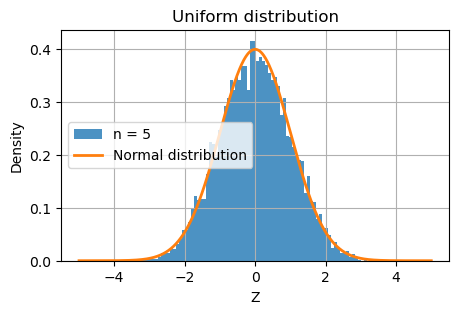

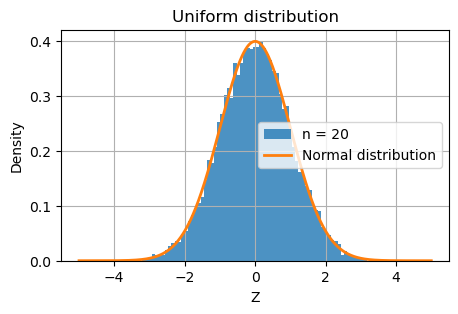

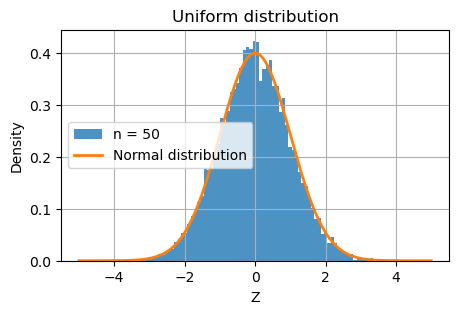

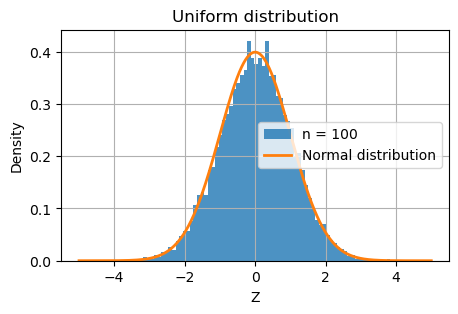

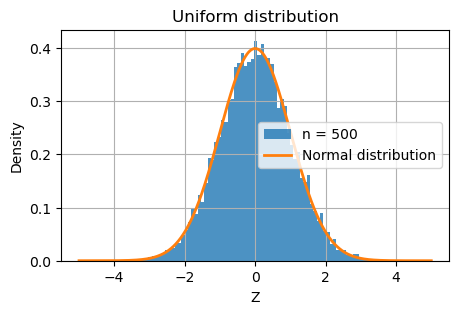

In [48]:
### CODE FOR UNIFORM ######################

mu_uniform = 0.5
sigma_uniform = np.sqrt(1/12)

for n in n_values:
    X = np.random.rand(totalnumber, n)
    S = np.sum(X, axis=1)
    Z = (S-n*mu_uniform)/(sigma_uniform*np.sqrt(n))
    
    
    plt.figure(figsize=(5,3))
    plt.hist(Z, bins=80, density=True, alpha=0.8, label=f"n = {n}")
    plt.plot(x, gausiana, linewidth=2, label='Normal distribution')
    plt.xlabel("Z")
    plt.ylabel("Density")
    plt.title("Uniform distribution")
    plt.grid()
    plt.legend()
    plt.show()
